# E(2) Equivariant Diffusion: Un Exemple Jouet en 2D

Ce notebook implémente l'expérience 2D proposée dans le rapport. L'objectif est de démontrer visuellement *pourquoi* l'équivariance E(n) est essentielle pour apprendre des distributions de données géométriques, comme indiqué dans le papier EDM.

**Hypothèse :**
1.  **Modèle 1 (GDM - Non-équivariant)** : Un MLP standard qui reçoit des coordonnées "aplaties" (`(B, N*2)`) échouera. Il fera la moyenne de toutes les rotations et produira un "anneau" de bruit flou.
2.  **Modèle 2 (E(2)-DM - Équivariant)** : Un EGNN qui implémente les principes d'équivariance du papier (en utilisant les distances relatives $d_{ij}$ et les vecteurs $\vec{x}_i - \vec{x}_j$) réussira. Il apprendra la *forme* abstraite de la constellation et la générera à n'importe quelle rotation.

In [266]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Création du Dataset 2D

Nous définissons une seule "constellation" de 5 points (une "maison") comme notre donnée de base. Le dataset d'entraînement sera composé de 10 000 copies de cette maison, chacune avec une rotation 2D et une translation aléatoires (la translation est annulée par la normalisation du centre de gravité, comme dans le papier).

Dataset shape: torch.Size([10000, 5, 2])


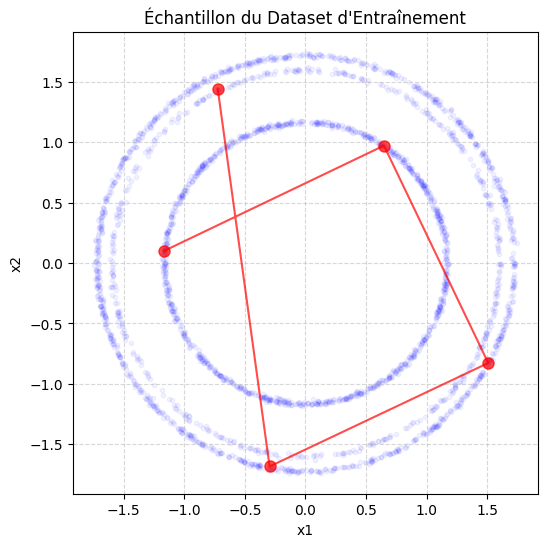

In [267]:
N = 5 # Nombre de "atomes" 2D

# 1. Définir la forme de la "maison"
x_true = torch.tensor([
    [0.0, 2.0],  # Pic du toit
    [-1.0, 1.0], # Coin sup gauche
    [1.0, 1.0],  # Coin sup droit
    [-1.0, -1.0],# Coin inf gauche
    [1.0, -1.0]  # Coin inf droit
], dtype=torch.float32)

# 2. Centrer la forme (pour la translation-invariance)
x_true -= torch.mean(x_true, dim=0, keepdim=True)

def create_dataset(num_samples, shape_true):
    dataset = torch.zeros(num_samples, N, 2)
    for i in range(num_samples):
        # Appliquer une rotation 2D aléatoire
        theta = torch.rand(1) * 2 * np.pi
        cos_t, sin_t = torch.cos(theta), torch.sin(theta)
        rot_matrix = torch.tensor([
            [cos_t, -sin_t],
            [sin_t,  cos_t]
        ]).squeeze()
        
        rotated_shape = shape_true @ rot_matrix.T
        dataset[i] = rotated_shape[torch.randperm(N), :] # random point order
    
    # Ajouter un tout petit peu de bruit pour éviter les zéros parfaits
    dataset += torch.randn_like(dataset) * 0.01
    return dataset.to(device)

dataset = create_dataset(10000, x_true)
print(f"Dataset shape: {dataset.shape}")

# Fonction de tracé (helper)
def plot_samples(samples, title, ax=None):
    if samples is None: return
    samples_cpu = samples.cpu().detach().numpy()
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    
    # Aplatir tous les échantillons pour le scatter plot
    ax.scatter(samples_cpu[:, :, 0].ravel(), 
               samples_cpu[:, :, 1].ravel(), 
               alpha=0.05, s=10, color='blue')
    
    # Tracer un échantillon en grand
    one_sample = samples_cpu[0]
    ax.plot(one_sample[:, 0], one_sample[:, 1], 'o-', color='red', markersize=8, alpha=0.7)
    
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.axis('equal')
    ax.grid(True, linestyle='--', alpha=0.5)

plot_samples(dataset[:500], "Échantillon du Dataset d'Entraînement")
plt.show()

## 2. Modèle de Diffusion (Base)

Nous définissons une classe de base `BaseDiffusion` qui gère le planning de bruit (`alpha`, `omega`), le `training_step`, et le `sample`. Les deux modèles (GDM et E(2)-DM) hériteront de cette classe, en ne surchargeant que `__init__` et `forward`.

In [268]:
class BaseDiffusion(nn.Module):
    def __init__(self, T=1000):
        super().__init__()
        self.T = T
        s = 1e-5
        
        # --- MODIFICATION : Schedule de Bruit Stabilisée ---
        
        # 1. Calculer la schedule "analytique" (instable)
        alpha_unstable = [(1-2*s)*(1 - (t/self.T)**2)+s for t in range(self.T+1)]
        alpha_unstable = torch.tensor(alpha_unstable, device=device, dtype=torch.float32)
        
        # 2. Calculer alpha_{t|t-1} = alpha_t / alpha_{t-1}
        # On ajoute alpha_{-1} = 1.0 au début pour le calcul
        alpha_unstable_padded = torch.cat([torch.tensor([1.0], device=device), alpha_unstable[:-1]])
        alpha_ts_unstable = alpha_unstable / alpha_unstable_padded
        
        # 3. Clipper alpha_{t|t-1}^2 comme dans le papier [cite: 481]
        alpha_ts_sq_clipped = torch.clamp(alpha_ts_unstable**2, min=0.001)
        alpha_ts_stable = torch.sqrt(alpha_ts_sq_clipped)
        
        # 4. Recalculer la schedule alpha stable en utilisant le produit cumulé [cite: 483]
        self.alpha = torch.cumprod(alpha_ts_stable, dim=0)
        
        # 5. Définir omega à partir de la schedule alpha stable
        self.omega = (1.0 - self.alpha**2).clamp(min=1e-8) # Clamp pour la stabilité du sqrt
        self.sqrt_omega = torch.sqrt(self.omega)
        
        # (Pour le training_step, ces alias sont OK)
        self.alpha_t = self.alpha
        self.omega_t = self.omega
        self.sqrt_omega_t = self.sqrt_omega
        
        print("Schedule de bruit stable initialisée.")
        
    def forward(self, x, t):
        # Doit être implémenté par les sous-classes
        raise NotImplementedError

    def training_step(self, x, optimizer):
        self.train()
        optimizer.zero_grad()

        B = x.shape[0]
        
        # t, eps_x, et centrage
        t_int = torch.randint(1, self.T + 1, (B, 1), device=device)
        eps_x = torch.randn_like(x, device=device)
        eps_x = eps_x - torch.mean(eps_x, dim=1, keepdim=True) # Centre le bruit

        # Diffusion step: x_t = alpha_t * x + omega_t * eps_x
        alpha_val = self.alpha_t[t_int].view(B, 1, 1)
        omega_val = self.sqrt_omega_t[t_int].view(B, 1, 1)
        x_t = alpha_val * x + omega_val * eps_x
        
        # Prédire le bruit
        eps_x_pred = self.forward(x_t, t_int.float())

        # Perte L2
        loss = torch.nn.functional.mse_loss(eps_x_pred, eps_x)
        
        loss.backward()
        optimizer.step()

        return {'loss': loss.detach().cpu().item()}

    @torch.no_grad()
    def sample(self, batch_size, N):
        self.eval()
        # Sampler z_T ~ N(0, I)
        x = torch.randn(batch_size, N, 2, device=device)
        x = x - torch.mean(x, dim=1, keepdim=True) # Doit être dans le sous-espace

        # Boucle de t=T à 1
        for t in reversed(range(1, self.T + 1)):
            t_tensor = torch.full((batch_size, 1), t, device=device).float()
            dx = self.forward(x, t_tensor)

            # Équations de sampling (simplifiées de l'Algorithme 2)
            t_idx = t
            s_idx = t - 1
            
            alpha_t = self.alpha[t_idx]
            omega_t = self.omega[t_idx]
            alpha_s = self.alpha[s_idx]
            omega_s = self.omega[s_idx]

            alpha_ts = alpha_t/alpha_s
            omega_ts = omega_t - alpha_ts**2 * omega_s
            omega_t_s_sq = (omega_ts * omega_s) / omega_t
            omega_t_s = np.sqrt(max(omega_t_s_sq, 1e-8))
            
            # Étape de reverse diffusion
            eps_x = 0.0
            if t > 1:
                eps_x = torch.randn_like(x)
                eps_x = eps_x - torch.mean(eps_x, dim=1, keepdim=True)

            # Formule de x_{t-1}
            term1 = x / alpha_ts
            term2 = (omega_ts / (alpha_ts * np.sqrt(omega_t))) * dx
            term3 = omega_t_s * eps_x
            x = term1 - term2 + term3
            
        return x

## 3. Modèle 1 : GDM (MLP Non-Équivariant)

Ce modèle "aplatit" les coordonnées d'entrée `(B, N, 2)` en `(B, N*2)`. Cet acte de `view()` ou `flatten()` **détruit** l'information de symétrie de rotation. Le modèle ne voit plus N points dans un espace 2D ; il voit un vecteur plat de 10 nombres.

In [269]:
class GDM_MLP(BaseDiffusion):
    def __init__(self, N, T=1000, nf_hidden=128):
        super().__init__(T)
        self.N = N
        self.nf_in = N * 2 # 5 * 2 = 10
        
        nf_time = 32
        self.time_mlp = nn.Sequential(
            nn.Linear(1, nf_time),
            nn.SiLU(),
            nn.Linear(nf_time, nf_time)
        )
        
        # Un simple MLP
        self.layers = nn.Sequential(
            nn.Linear(self.nf_in + nf_time, nf_hidden),
            nn.SiLU(),
            nn.Linear(nf_hidden, nf_hidden),
            nn.SiLU(),
            nn.Linear(nf_hidden, self.nf_in) # Sortie : bruit applati
        )

    def forward(self, x, t):
        B = x.shape[0]
        
        # --- L'ÉTAPE NON-ÉQUIVARIANTE --- 
        x_flat = x.view(B, -1)
        
        t_embed = self.time_mlp(t / self.T)
        h = torch.cat([x_flat, t_embed], dim=-1)
        
        eps_flat_pred = self.layers(h)
        
        # Reformater à la bonne taille de sortie
        return eps_flat_pred.view(B, self.N, 2)

## 4. Modèle 2 : E(2)-DM (EGNN Équivariant)

Ce modèle implémente les principes de l'EGNN du papier en 2D. Il n'aplatit jamais les coordonnées. Il n'utilise que des opérations E(2)-invariantes (distances $d_{ij}$) et E(2)-équivariantes (vecteurs $\vec{x}_i - \vec{x}_j$).

In [270]:
class E2DM_EGNN(BaseDiffusion):
    def __init__(self, N, T=1000, L=4, nf=64):
        super().__init__(T)
        self.N = N
        self.nf = nf
        self.L = L
        self.init_weight()

    def init_weight(self):
        self.phi_e = nn.ModuleList()
        self.phi_x = nn.ModuleList()
        self.phi_h = nn.ModuleList()

        # La seule feature d'entrée est le temps 't'
        nf_in = 1 
        self.h_embed = nn.Linear(nf_in, self.nf)

        for _ in range(self.L):
            # phi_e : [h_i, h_j, d_ij^2] -> m_ij
            self.phi_e.append(nn.Sequential(
                nn.Linear(self.nf * 2 + 1, self.nf),
                nn.SiLU(),
                nn.Linear(self.nf, self.nf)
            ))

            # phi_x : [h_i, h_j, d_ij^2] -> scalar weight
            self.phi_x.append(nn.Sequential(
                nn.Linear(self.nf * 2 + 1, self.nf),
                nn.SiLU(),
                nn.Linear(self.nf, 1)
            ))

            # phi_h : [h_i, m_agg] -> h_i_new
            self.phi_h.append(nn.Sequential(
                nn.Linear(self.nf + self.nf, self.nf),
                nn.SiLU(),
                nn.Linear(self.nf, self.nf)
            ))

    def forward(self, x, t):
        B = x.shape[0]
        x0 = x.clone() # Sauvegarder l'entrée z_t

        # h est juste l'embedding du temps
        t_embed = (t / self.T).expand(B, self.N).unsqueeze(-1)
        h = self.h_embed(t_embed) # (B, N, nf)

        for l in range(self.L):
            # --- OPÉRATIONS ÉQUIVARIANTES --- 
            
            # 1. Vecteurs de différence (Équivariant)
            diff = x.unsqueeze(2) - x.unsqueeze(1) # (B, N, N, 2)
            
            # 2. Distances au carré (Invariant)
            d_ij_sq = (diff ** 2).sum(dim=-1, keepdim=True).clamp(min=1e-9) # (B, N, N, 1)

            # 3. Préparer les features pour la diffusion (broadcasting)
            h_i = h.unsqueeze(2).expand(-1, -1, self.N, -1) # (B, N, N, nf)
            h_j = h.unsqueeze(1).expand(-1, self.N, -1, -1) # (B, N, N, nf)
            
            # [h_i, h_j, d_ij^2] -> (B, N, N, nf*2 + 1)
            features = torch.cat([h_i, h_j, d_ij_sq], dim=-1)

            # 4. Calculer les messages (phi_e) et les poids des coordonnées (phi_x)
            m_ij = self.phi_e[l](features) # (B, N, N, nf)
            phi_x_w = self.phi_x[l](features) # (B, N, N, 1)

            # 5. Mettre à jour les coordonnées (Équivariant)
            # x_i_new = x_i + sum_j( (x_i - x_j) * w )
            update_vec = diff * phi_x_w / (torch.sqrt(d_ij_sq) + 1.0)
            x = x + update_vec.sum(dim=2) # Somme sur j
            
            # 6. Mettre à jour les features (Invariant)
            mask = ~torch.eye(self.N, dtype=bool, device=device).unsqueeze(0).unsqueeze(-1)
            m_agg = (m_ij * mask).sum(dim=2) # (B, N, nf)
            
            h_new = self.phi_h[l](torch.cat([h, m_agg], dim=-1))
            h = h + h_new # Connexion résiduelle

        # Objectif de prédiction
        eps_x_pred = x - x0
        # Projeter à nouveau sur le sous-espace à centre de gravité nul
        eps_x_pred = eps_x_pred - torch.mean(eps_x_pred, dim=1, keepdim=True)
        
        return eps_x_pred

## 5. Entraînement et Comparaison des Résultats

In [287]:
# Initialiser les modèles
gdm_model = GDM_MLP(N=N).to(device)
e2dm_model = E2DM_EGNN(N=N, L=3, nf=32).to(device)

print("e2dm param count :", sum([np.prod(p.size()) for p in e2dm_model.parameters()]))
print("gdm param count :", sum([np.prod(p.size()) for p in gdm_model.parameters()]))

Schedule de bruit stable initialisée.
Schedule de bruit stable initialisée.
e2dm param count : 25411
gdm param count : 24426


In [288]:
# Paramètres d'entraînement
MAX_ITER = 10001
BATCH_SIZE = 128
LR = 1e-4

optim_gdm = optim.Adam(gdm_model.parameters(), lr=LR)
optim_e2dm = optim.Adam(e2dm_model.parameters(), lr=LR)

print("Démarrage de l'entraînement...")
for i in range(MAX_ITER):
    # Échantillonner un batch d'entraînement
    idx = torch.randint(0, len(dataset), (BATCH_SIZE,))
    batch = dataset[idx]
    
    # Entraîner les deux modèles sur le MÊME batch
    logs_gdm = gdm_model.training_step(batch, optim_gdm)
    logs_e2dm = e2dm_model.training_step(batch, optim_e2dm)
    
    if i % 1000 == 0:
        print(f"--- Iteration {i} ---")
        print(f"  GDM (MLP) Loss:   {logs_gdm['loss']:.6f}")
        print(f"  E2DM (EGNN) Loss: {logs_e2dm['loss']:.6f}")

print("Entraînement terminé.")

Démarrage de l'entraînement...
--- Iteration 0 ---
  GDM (MLP) Loss:   0.831674
  E2DM (EGNN) Loss: 0.784665
--- Iteration 1000 ---
  GDM (MLP) Loss:   0.485430
  E2DM (EGNN) Loss: 0.359344
--- Iteration 2000 ---
  GDM (MLP) Loss:   0.493536
  E2DM (EGNN) Loss: 0.314860
--- Iteration 3000 ---
  GDM (MLP) Loss:   0.458867
  E2DM (EGNN) Loss: 0.303418
--- Iteration 4000 ---
  GDM (MLP) Loss:   0.485224
  E2DM (EGNN) Loss: 0.288369
--- Iteration 5000 ---
  GDM (MLP) Loss:   0.418971
  E2DM (EGNN) Loss: 0.305686
--- Iteration 6000 ---
  GDM (MLP) Loss:   0.457801
  E2DM (EGNN) Loss: 0.256108
--- Iteration 7000 ---
  GDM (MLP) Loss:   0.460387
  E2DM (EGNN) Loss: 0.262138
--- Iteration 8000 ---
  GDM (MLP) Loss:   0.478968
  E2DM (EGNN) Loss: 0.234543
--- Iteration 9000 ---
  GDM (MLP) Loss:   0.437681
  E2DM (EGNN) Loss: 0.230096
--- Iteration 10000 ---
  GDM (MLP) Loss:   0.398299
  E2DM (EGNN) Loss: 0.250421
Entraînement terminé.


## 6. Résultats : Échantillonnage et Analyse

Maintenant, nous générons 500 échantillons de chaque modèle entraîné et nous les traçons.

**Résultat Attendu :**
* **GDM (MLP)** : Une "boule" ou un "anneau" flou. Le modèle a fait la moyenne de toutes les rotations qu'il a vues.
* **E2DM (EGNN)** : Des formes de "maison" claires et nettes, mais à différentes orientations aléatoires.

Génération d'échantillons...


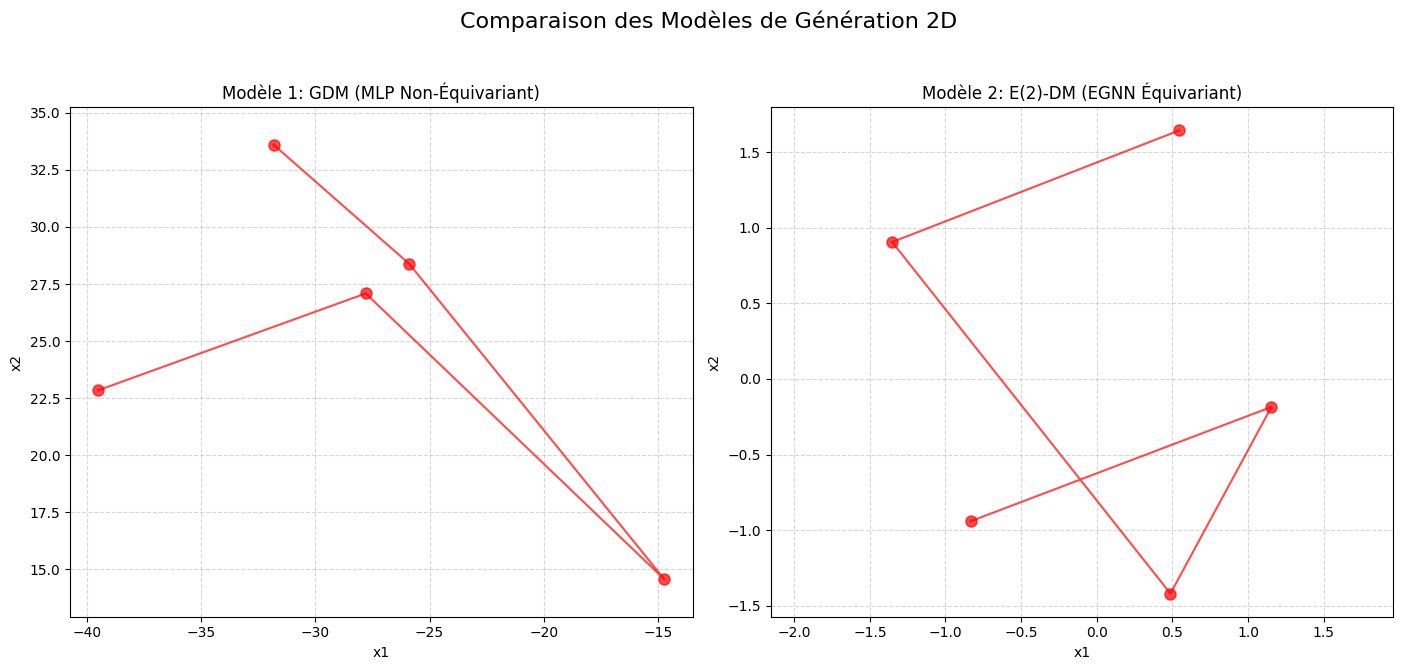

In [290]:
print("Génération d'échantillons...")
# Générer des échantillons des deux modèles
gdm_samples = gdm_model.sample(batch_size=1, N=N)
e2dm_samples = e2dm_model.sample(batch_size=1, N=N)

# Créer une figure avec deux sous-graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

fig.suptitle("Comparaison des Modèles de Génération 2D", fontsize=16)

# Tracer les résultats du GDM
plot_samples(gdm_samples, "Modèle 1: GDM (MLP Non-Équivariant)", ax=ax1)
ax1.set_title("Modèle 1: GDM (MLP Non-Équivariant)")

# Tracer les résultats de l'E(2)-DM
plot_samples(e2dm_samples, "Modèle 2: E(2)-DM (EGNN Équivariant)", ax=ax2)
ax2.set_title("Modèle 2: E(2)-DM (EGNN Équivariant)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [273]:

# Sampler z_T ~ N(0, I)
batch_size = 1
x = torch.randn(batch_size, N, 2, device=device)
x = x - torch.mean(x, dim=1, keepdim=True) # Doit être dans le sous-espace

# Boucle de t=T à 1
for t in reversed(range(1, e2dm_model.T + 1)):
    t_tensor = torch.full((batch_size, 1), t, device=device).float()
    dx = e2dm_model.forward(x, t_tensor)

    # Équations de sampling (simplifiées de l'Algorithme 2)
    t_idx = t
    s_idx = t - 1

    alpha_t = e2dm_model.alpha[t_idx]
    omega_t = e2dm_model.omega[t_idx]
    alpha_s = e2dm_model.alpha[s_idx]
    omega_s = e2dm_model.omega[s_idx]

    alpha_ts = alpha_t/alpha_s
    omega_ts = omega_t - alpha_ts**2 * omega_s
    omega_t_s_sq = (omega_ts * omega_s) / omega_t
    omega_t_s = np.sqrt(max(omega_t_s_sq, 1e-8))
    print(omega_ts)

    # Étape de reverse diffusion
    eps_x = 0.0
    if t > 1:
        eps_x = torch.randn_like(x)
        eps_x = eps_x - torch.mean(eps_x, dim=1, keepdim=True)

    # Formule de x_{t-1}
    term1 = x / alpha_ts
    term2 = (omega_ts / (alpha_ts * np.sqrt(omega_t))) * dx
    term3 = omega_t_s * eps_x
    x = term1 - term2 + term3
    print(x)



tensor(0.9990)
tensor([[[-0.6900,  1.5756],
         [-0.5722,  0.8747],
         [ 2.2158,  0.1918],
         [-1.1128, -0.8926],
         [ 0.1591, -1.7494]]], grad_fn=<AddBackward0>)
tensor(0.7485)
tensor([[[-0.8169,  1.6689],
         [-0.3002,  0.9254],
         [ 0.9489,  0.1773],
         [-0.9125, -0.5072],
         [ 1.0807, -2.2644]]], grad_fn=<AddBackward0>)
tensor(0.5544)
tensor([[[-1.1538,  1.7746],
         [ 1.0109,  0.1065],
         [ 1.1275, -0.5877],
         [-2.2599, -0.9555],
         [ 1.2753, -0.3379]]], grad_fn=<AddBackward0>)
tensor(0.4365)
tensor([[[-0.5765,  0.3097],
         [ 0.2314,  0.2158],
         [ 1.3704, -0.1880],
         [-1.5586, -0.8037],
         [ 0.5333,  0.4661]]], grad_fn=<AddBackward0>)
tensor(0.3590)
tensor([[[-1.0105,  0.4967],
         [ 0.7180, -0.4281],
         [ 0.6038,  0.0357],
         [-1.3755,  0.0307],
         [ 1.0643, -0.1350]]], grad_fn=<AddBackward0>)
tensor(0.3046)
tensor([[[-0.9482,  1.3442],
         [ 0.3392, -0.4111

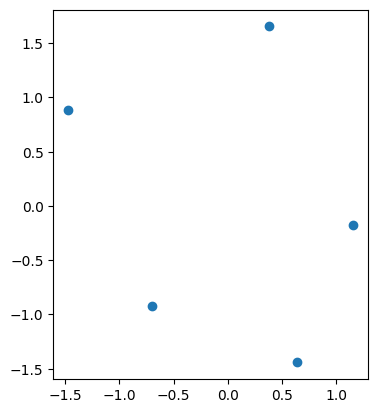

In [274]:
x = x.detach()
plt.scatter(x[0, :, 0], x[0, :, 1])
plt.gca().set_aspect('equal')

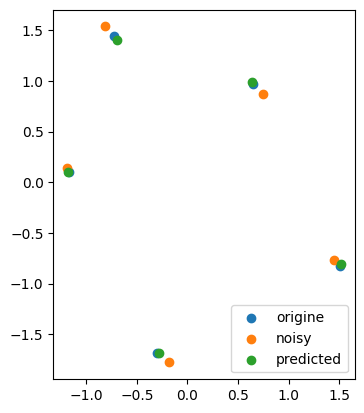

In [275]:
base = dataset[0]

B = 1
        
# t, eps_x, et centrage
t_int = torch.randint(1, e2dm_model.T + 1, (B, 1), device=device)
eps_x = torch.randn_like(base, device=device)
eps_x = eps_x - torch.mean(eps_x, dim=1, keepdim=True) # Centre le bruit

# Diffusion step: x_t = alpha_t * x + omega_t * eps_x
alpha_val = e2dm_model.alpha_t[t_int].view(B, 1, 1)
omega_val = e2dm_model.sqrt_omega_t[t_int].view(B, 1, 1)
x_t = alpha_val * base + omega_val * eps_x
x_t -= torch.mean(x_t, axis=1, keepdim=True)

# Prédire le bruit
eps_x_pred = e2dm_model.forward(x_t, t_int.float())
rec = (x_t - omega_val * eps_x_pred.detach()) / alpha_val
rec -= torch.mean(rec, axis=1, keepdim=True)
plt.scatter(base[:, 0], base[:, 1], label="origine")
plt.scatter(x_t[0, :, 0], x_t[0, :, 1], label="noisy")
plt.scatter(rec[0, :, 0], rec[0, :, 1], label="predicted")
plt.gca().set_aspect('equal')
plt.legend()
